# Training Output Analysis

This notebook analyzes the artifacts generated by `train_model.py`.

Expected files:
- `training/reports/metrics.json`
- `training/reports/test_predictions.csv`
- `training/reports/feature_coefficients.csv`
- `training/models/feature_names.json` (optional)


In [17]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

BASE_DIR = Path.cwd().parent
REPORT_DIR = BASE_DIR / 'reports'
MODEL_DIR = BASE_DIR / 'models'

metrics_path = REPORT_DIR / 'metrics.json'
predictions_path = REPORT_DIR / 'test_predictions.csv'
coefficients_path = REPORT_DIR / 'feature_coefficients.csv'
feature_names_path = MODEL_DIR / 'feature_names.json'

print('REPORT_DIR =', REPORT_DIR)
print('metrics.json exists:', metrics_path.exists())
print('test_predictions.csv exists:', predictions_path.exists())
print('feature_coefficients.csv exists:', coefficients_path.exists())
print('feature_names.json exists:', feature_names_path.exists())


REPORT_DIR = /home/lucas/Invest/training/reports
metrics.json exists: True
test_predictions.csv exists: True
feature_coefficients.csv exists: True
feature_names.json exists: True


## 1. Metrics summary

In [18]:
metrics = None
if metrics_path.exists():
    with open(metrics_path, 'r', encoding='utf-8') as f:
        metrics = json.load(f)
    metrics_df = pd.DataFrame([
        {'metric': k, 'value': v} for k, v in metrics.items()
    ])
    display(metrics_df)
else:
    print('metrics.json not found.')


,metric,value
0,threshold,0.500000
1,train_accuracy,0.539004
2,test_accuracy,0.529016
3,train_roc_auc,0.546885
4,test_roc_auc,0.525688
5,train_rows,633533.000000
6,test_rows,199111.000000
7,num_features,31.000000


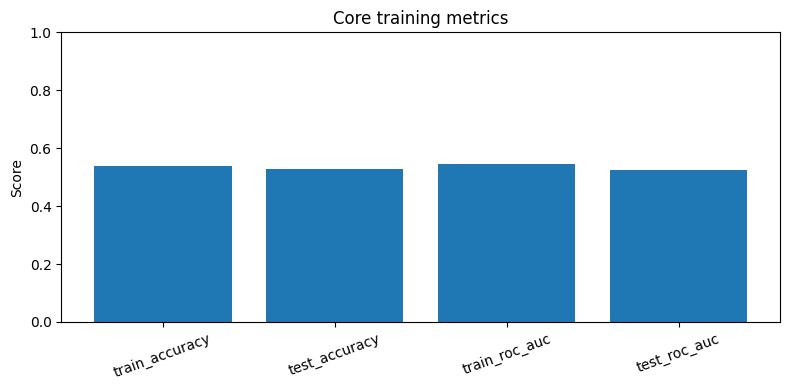

In [19]:
if metrics is not None:
    plot_keys = [
        k for k in ['train_accuracy', 'test_accuracy', 'train_roc_auc', 'test_roc_auc']
        if k in metrics
    ]
    if plot_keys:
        plt.figure(figsize=(8, 4))
        plt.bar(plot_keys, [metrics[k] for k in plot_keys])
        plt.ylim(0, 1)
        plt.ylabel('Score')
        plt.title('Core training metrics')
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()


## 2. Prediction file overview

In [20]:
preds = None
if predictions_path.exists():
    preds = pd.read_csv(predictions_path, parse_dates=['trade_date'])
    display(preds.head())
    print('Rows:', len(preds))
    print('Symbols:', preds['symbol'].nunique())
    print('Date range:', preds['trade_date'].min(), '->', preds['trade_date'].max())
else:
    print('test_predictions.csv not found.')


,trade_date,symbol,target_5d,target_up_5d,pred_proba_up_5d
0,2023-12-27,BGIP3,-0.010745,0,0.645738
1,2023-12-27,GSHP3,-0.187638,0,0.630914
2,2023-12-27,CEEB3,0.012017,1,0.534586
3,2023-12-27,VSTE3,-0.011111,0,0.531997
4,2023-12-27,PGMN3,-0.100515,0,0.525789


Rows: 199111
Symbols: 378
Date range: 2023-12-27 00:00:00 -> 2026-03-24 00:00:00


Target distribution:


target_up_5d
0    0.544169
1    0.455831
Name: proportion, dtype: float64

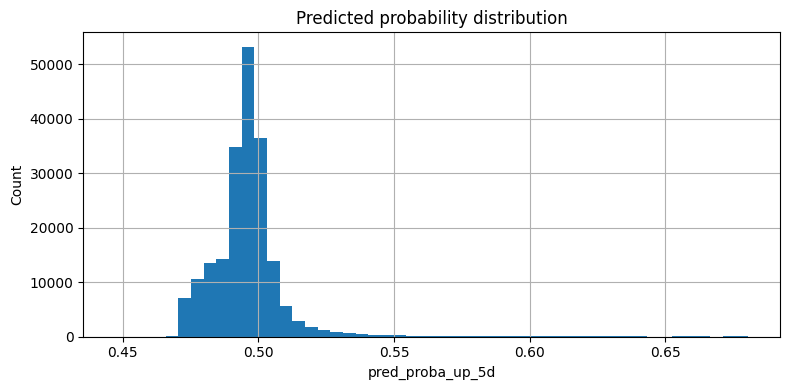

In [21]:
if preds is not None:
    print('Target distribution:')
    display(preds['target_up_5d'].value_counts(normalize=True).rename('proportion').sort_index())
    
    plt.figure(figsize=(8, 4))
    preds['pred_proba_up_5d'].hist(bins=50)
    plt.title('Predicted probability distribution')
    plt.xlabel('pred_proba_up_5d')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


## 3. Evaluate different thresholds

In [22]:
if preds is not None:
    thresholds = np.arange(0.30, 0.71, 0.05)
    rows = []
    y_true = preds['target_up_5d'].to_numpy()
    proba = preds['pred_proba_up_5d'].to_numpy()
    
    for threshold in thresholds:
        y_pred = (proba >= threshold).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        precision_1 = tp / (tp + fp) if (tp + fp) else np.nan
        recall_1 = tp / (tp + fn) if (tp + fn) else np.nan
        rows.append({
            'threshold': threshold,
            'accuracy': accuracy_score(y_true, y_pred),
            'precision_class_1': precision_1,
            'recall_class_1': recall_1,
            'predicted_positive_ratio': y_pred.mean(),
        })
    threshold_df = pd.DataFrame(rows)
    display(threshold_df)
else:
    print('Predictions file not available.')


,threshold,accuracy,precision_class_1,recall_class_1,predicted_positive_ratio
0,0.30,0.455831,0.455831,1.000000,1.000000
1,0.35,0.455831,0.455831,1.000000,1.000000
2,0.40,0.455831,0.455831,1.000000,1.000000
3,0.45,0.455836,0.455833,1.000000,0.999995
4,0.50,0.529016,0.470012,0.260497,0.252638
5,0.55,0.542110,0.376208,0.006864,0.008317
6,0.60,0.543260,0.312629,0.001664,0.002426
7,0.65,0.543737,0.263736,0.000529,0.000914
8,0.70,0.544169,NaN,0.000000,0.000000


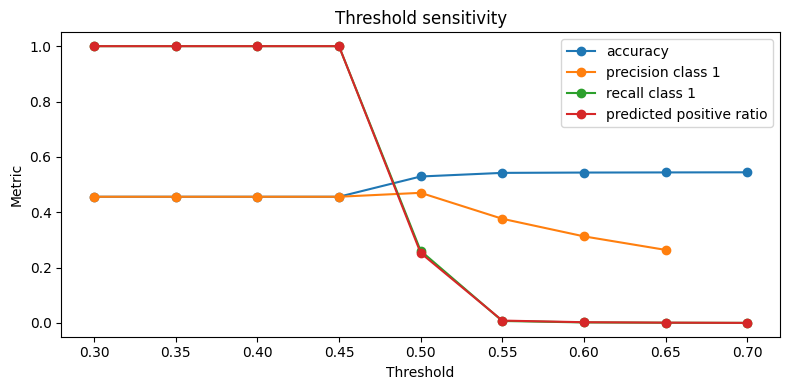

In [23]:
if preds is not None:
    plt.figure(figsize=(8, 4))
    plt.plot(threshold_df['threshold'], threshold_df['accuracy'], marker='o', label='accuracy')
    plt.plot(threshold_df['threshold'], threshold_df['precision_class_1'], marker='o', label='precision class 1')
    plt.plot(threshold_df['threshold'], threshold_df['recall_class_1'], marker='o', label='recall class 1')
    plt.plot(threshold_df['threshold'], threshold_df['predicted_positive_ratio'], marker='o', label='predicted positive ratio')
    plt.title('Threshold sensitivity')
    plt.xlabel('Threshold')
    plt.ylabel('Metric')
    plt.legend()
    plt.tight_layout()
    plt.show()


## 4. ROC and precision-recall curves

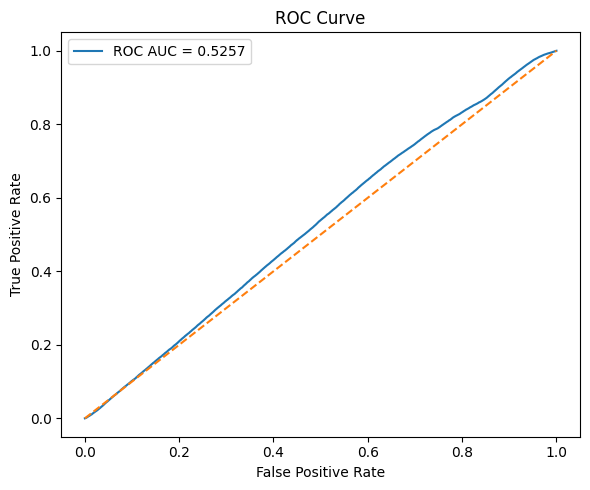

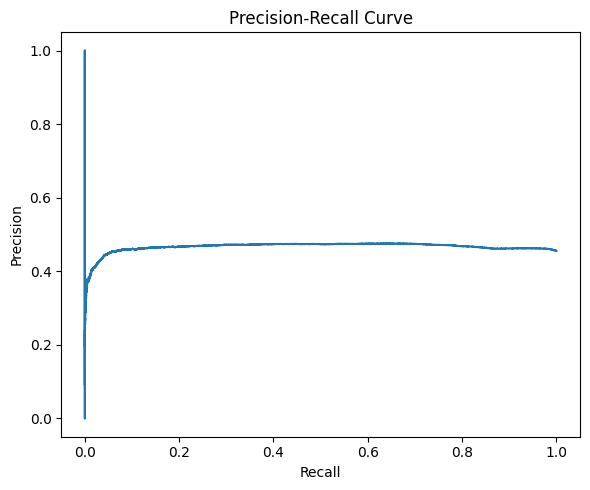

In [24]:
if preds is not None:
    y_true = preds['target_up_5d'].to_numpy()
    proba = preds['pred_proba_up_5d'].to_numpy()
    
    auc = roc_auc_score(y_true, proba)
    fpr, tpr, _ = roc_curve(y_true, proba)
    precision, recall, _ = precision_recall_curve(y_true, proba)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.tight_layout()
    plt.show()


## 5. Top confident predictions

In [25]:
if preds is not None:
    top_up = preds.sort_values('pred_proba_up_5d', ascending=False).head(20)
    top_down = preds.sort_values('pred_proba_up_5d', ascending=True).head(20)
    print('Top 20 strongest UP predictions')
    display(top_up)
    print('Top 20 strongest DOWN predictions')
    display(top_down)


Top 20 strongest UP predictions


,trade_date,symbol,target_5d,target_up_5d,pred_proba_up_5d
110219,2025-04-01,ESTR3,0.000000,0,0.680586
34892,2024-05-22,EKTR3,0.018158,1,0.680247
159176,2025-10-14,EKTR3,-0.104348,0,0.678939
74757,2024-10-30,RPAD3,0.000000,0,0.678921
33839,2024-05-17,PATI3,0.000000,0,0.678559
138845,2025-07-28,ENMT3,-0.046875,0,0.678544
106676,2025-03-18,CBEE3,-0.153846,0,0.678439
3172,2024-01-11,ESTR3,0.000000,0,0.678404
57610,2024-08-22,CBEE3,0.000000,0,0.678364
24360,2024-04-09,CBEE3,-0.011725,0,0.678352


Top 20 strongest DOWN predictions


,trade_date,symbol,target_5d,target_up_5d,pred_proba_up_5d
144270,2025-08-15,RVEE3,-0.333333,0,0.447089
144634,2025-08-18,RVEE3,-0.187585,0,0.451443
143908,2025-08-14,RVEE3,0.234568,1,0.456983
144998,2025-08-19,RVEE3,-0.143725,0,0.458589
145723,2025-08-21,RVEE3,0.138095,1,0.468175
144997,2025-08-19,CCTY3,0.069996,1,0.468455
144633,2025-08-18,CCTY3,0.043705,1,0.468790
186909,2026-02-03,MWET4,-0.245926,0,0.468834
140290,2025-07-31,RVEE3,0.006289,1,0.468899
141012,2025-08-04,RVEE3,0.411043,1,0.469069


## 6. Relationship between predicted probability and realized 5-day return

,proba_bin,mean_pred_proba,realized_up_rate,mean_target_5d,count
0,"(0.446, 0.481]",0.476737,0.396495,0.000863,19912
1,"(0.481, 0.487]",0.484016,0.423334,0.000469,19911
2,"(0.487, 0.491]",0.489737,0.426849,0.000406,19911
3,"(0.491, 0.494]",0.492572,0.460248,0.000989,19911
4,"(0.494, 0.496]",0.494725,0.482949,0.001500,19911
5,"(0.496, 0.497]",0.496461,0.471046,0.000006,19911
6,"(0.497, 0.499]",0.498134,0.481242,0.000765,19911
7,"(0.499, 0.501]",0.500090,0.482849,0.001199,19911
8,"(0.501, 0.506]",0.503201,0.472201,-0.000562,19911
9,"(0.506, 0.681]",0.521157,0.461102,0.001937,19911


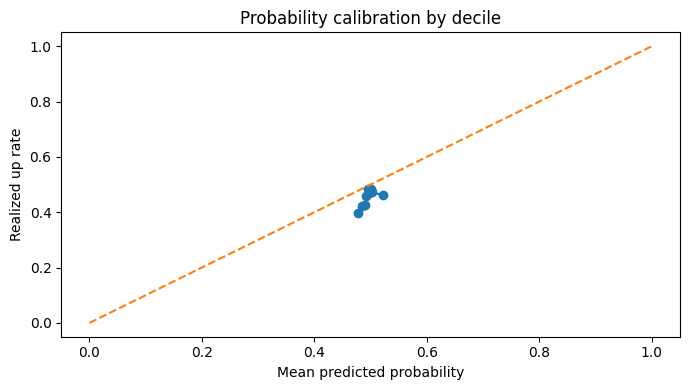

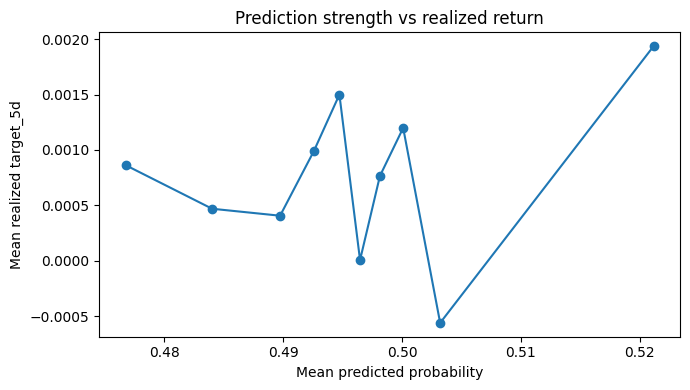

In [26]:
if preds is not None:
    preds['proba_bin'] = pd.qcut(preds['pred_proba_up_5d'], q=10, duplicates='drop')
    calibration_df = preds.groupby('proba_bin').agg(
        mean_pred_proba=('pred_proba_up_5d', 'mean'),
        realized_up_rate=('target_up_5d', 'mean'),
        mean_target_5d=('target_5d', 'mean'),
        count=('target_up_5d', 'size'),
    ).reset_index()
    display(calibration_df)
    
    plt.figure(figsize=(7, 4))
    plt.plot(calibration_df['mean_pred_proba'], calibration_df['realized_up_rate'], marker='o')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Realized up rate')
    plt.title('Probability calibration by decile')
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(7, 4))
    plt.plot(calibration_df['mean_pred_proba'], calibration_df['mean_target_5d'], marker='o')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Mean realized target_5d')
    plt.title('Prediction strength vs realized return')
    plt.tight_layout()
    plt.show()


## 7. Feature coefficients

In [27]:
coef_df = None
if coefficients_path.exists():
    coef_df = pd.read_csv(coefficients_path)
    display(coef_df.head(20))
else:
    print('feature_coefficients.csv not found.')


,feature,coefficient,abs_coefficient
0,sector_Desconhecido,-0.052039,0.052039
1,volume_ratio_20d,0.038965,0.038965
2,price_sma_20_ratio,-0.026018,0.026018
3,sector_Energia,0.015532,0.015532
4,sector_Outros,-0.013565,0.013565
5,sector_Consumo Não Cíclico,0.012590,0.012590
6,return_5d_vs_sector,-0.012053,0.012053
7,sector_Construção e Imobiliário,-0.011919,0.011919
8,sector_Materiais Básicos,0.010508,0.010508
9,return_5d,-0.008647,0.008647


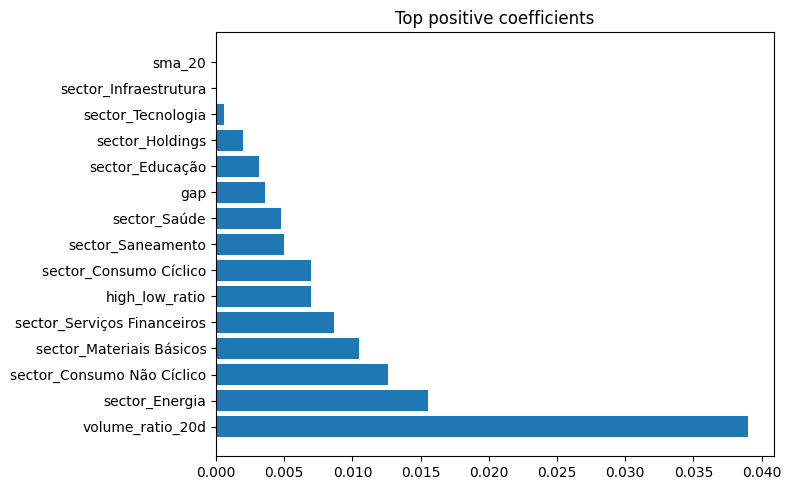

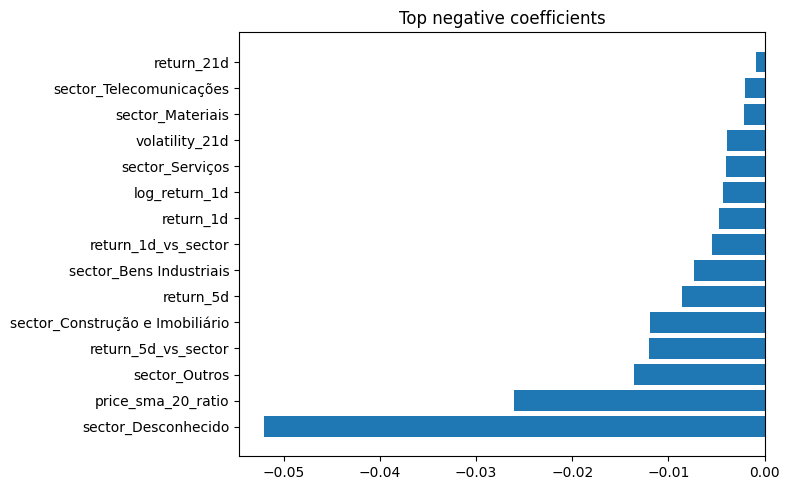

In [28]:
if coef_df is not None:
    top_positive = coef_df.sort_values('coefficient', ascending=False).head(15)
    top_negative = coef_df.sort_values('coefficient', ascending=True).head(15)
    
    plt.figure(figsize=(8, 5))
    plt.barh(top_positive['feature'], top_positive['coefficient'])
    plt.title('Top positive coefficients')
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(8, 5))
    plt.barh(top_negative['feature'], top_negative['coefficient'])
    plt.title('Top negative coefficients')
    plt.tight_layout()
    plt.show()
